#### Import Libraries

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.metrics import roc_curve, auc

#### Import Evaluation Resutls

In [2]:
%store -r lr_conf_matrix
%store -r rf_conf_matrix
%store -r knn_conf_matrix
%store -r nb_conf_matrix
%store -r svm_conf_matrix

### Confusion Matrix

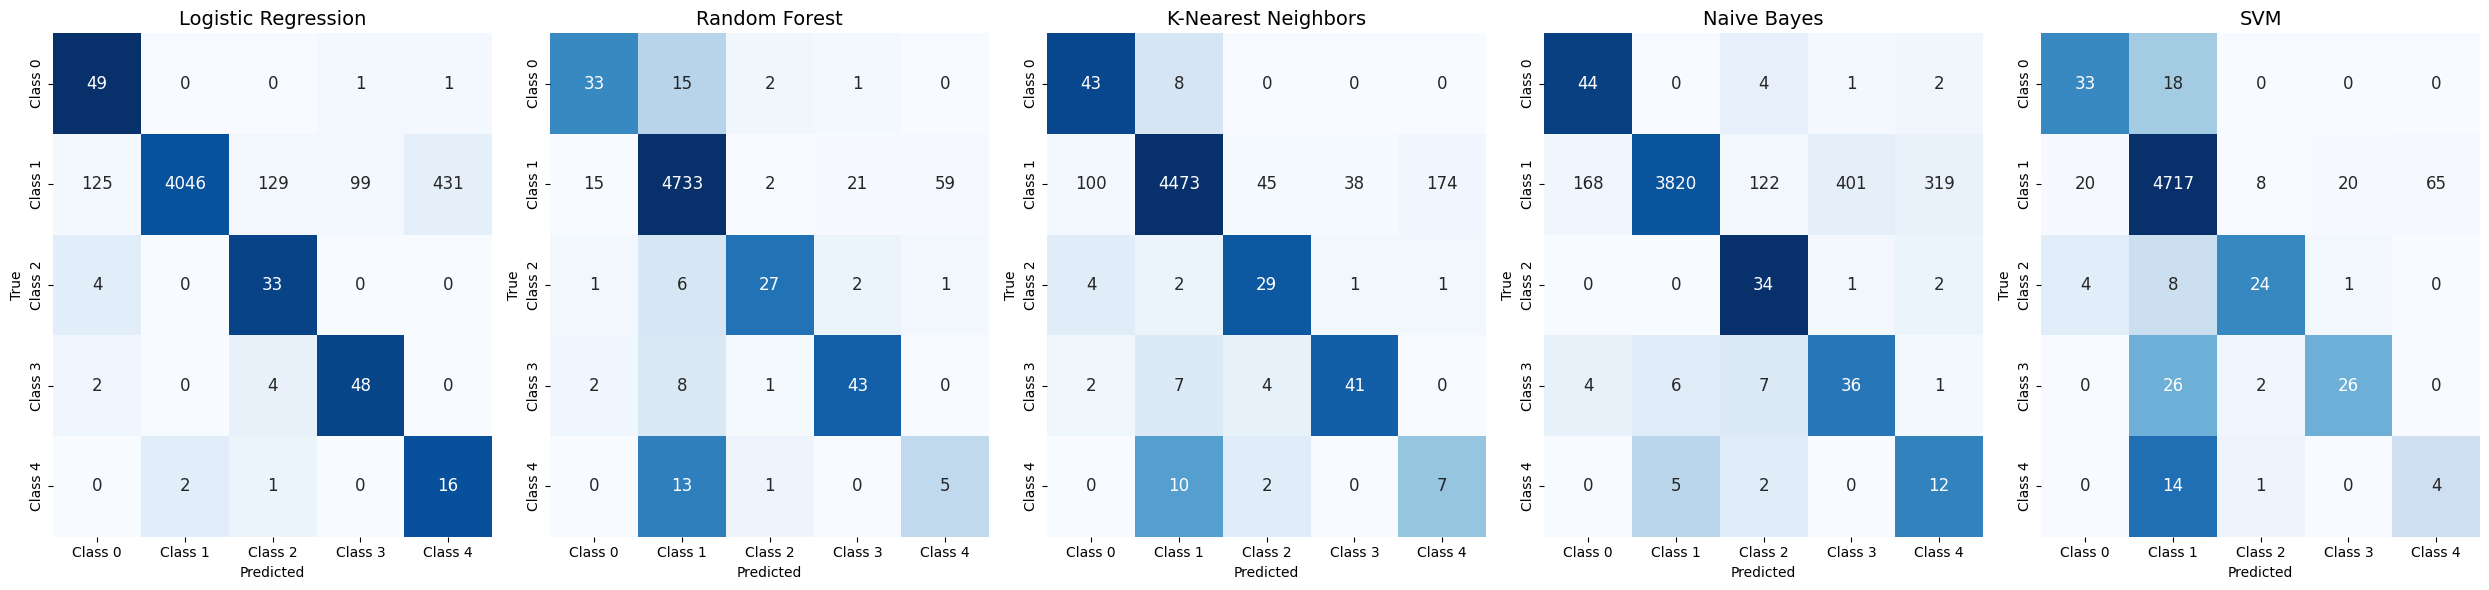

In [3]:
conf_matrices = [lr_conf_matrix, rf_conf_matrix, knn_conf_matrix, nb_conf_matrix, svm_conf_matrix]
titles = ['Logistic Regression', 'Random Forest', 'K-Nearest Neighbors', 'Naive Bayes', 'SVM']

class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4'] 

fig, axes = plt.subplots(1, 5, figsize=(25, 6))

for i, (conf_matrix, title) in enumerate(zip(conf_matrices, titles)):
    conf_matrix_normalized = conf_matrix.astype(float) / conf_matrix.sum(axis=1)[:, np.newaxis]
    
    conf_matrix_df = pd.DataFrame(conf_matrix, index=class_names, columns=class_names)
    conf_matrix_normalized_df = pd.DataFrame(conf_matrix_normalized, index=class_names, columns=class_names)
    
    sns.heatmap(
        conf_matrix_normalized_df, 
        annot=conf_matrix_df.values,  
        fmt='d',  
        cmap='Blues', 
        cbar=False,
        ax=axes[i],  
        annot_kws={"size": 12},  
        xticklabels=class_names, 
        yticklabels=class_names
    )
    
    axes[i].set_title(title, fontsize=14)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

plt.tight_layout()
plt.show()

### Training Time

In [4]:
%store -r lr_training_time
%store -r rf_training_time
%store -r knn_training_time
%store -r nb_training_time
%store -r svm_training_time

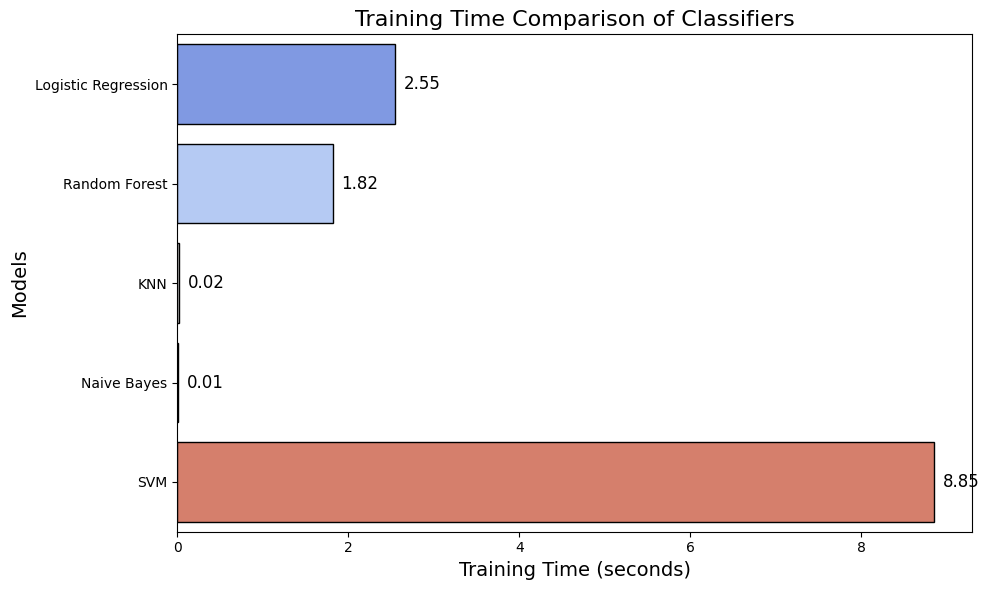

In [5]:
training_times = [lr_training_time, rf_training_time, knn_training_time, nb_training_time, svm_training_time]
models = ['Logistic Regression', 'Random Forest', 'KNN', 'Naive Bayes', 'SVM']

plt.figure(figsize=(10, 6))

sns.barplot(y=models, x=training_times, palette='coolwarm', edgecolor='black')

plt.ylabel('Models', fontsize=14)
plt.xlabel('Training Time (seconds)', fontsize=14)
plt.title('Training Time Comparison of Classifiers', fontsize=16)

for i, v in enumerate(training_times):
    plt.text(v + 0.1, i, f"{v:.2f}", va='center', fontsize=12)

plt.tight_layout()
plt.show()

In [6]:
%store -r lr_prediction_time
%store -r rf_prediction_time
%store -r knn_prediction_time
%store -r nb_prediction_time
%store -r svm_prediction_time

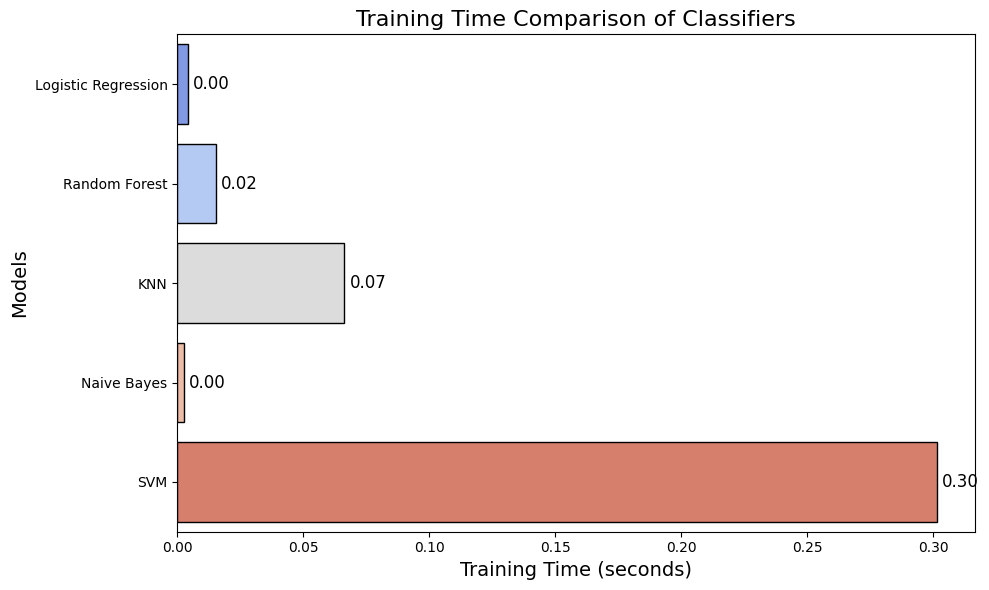

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming the training times are stored in variables
training_times = [lr_prediction_time, rf_prediction_time, knn_prediction_time, nb_prediction_time, svm_prediction_time]
models = ['Logistic Regression', 'Random Forest', 'KNN', 'Naive Bayes', 'SVM']

# Set up the figure size
plt.figure(figsize=(10, 6))

# Create a horizontal bar plot using seaborn
sns.barplot(y=models, x=training_times, palette='coolwarm', edgecolor='black')

# Add labels and title
plt.ylabel('Models', fontsize=14)
plt.xlabel('Training Time (seconds)', fontsize=14)
plt.title('Training Time Comparison of Classifiers', fontsize=16)

# Display the values at the end of the bars
for i, v in enumerate(training_times):
    plt.text(v+0.002, i, f"{v:.2f}", va='center', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()


In [9]:
%store -r lr_class_report
%store -r rf_class_report
%store -r knn_class_report
%store -r nb_class_report
%store -r svm_class_report

In [20]:
class_label_mapping = {
    '0': 'Heat Dissipation Failure',
    '1': 'No Failure',
    '2': 'Overstrain Failure',
    '3': 'Power Failure',
    '4': 'Tool Wear Failure'
}

def update_class_report(class_report, label_mapping):
    updated_report = {}
    for key, value in class_report.items():
        if key in label_mapping:
            updated_report[label_mapping[key]] = value
        else:
            updated_report[key] = value
    return updated_report

lr_class_report = update_class_report(lr_class_report, class_label_mapping)
rf_class_report = update_class_report(rf_class_report, class_label_mapping)
knn_class_report = update_class_report(knn_class_report, class_label_mapping)
nb_class_report = update_class_report(nb_class_report, class_label_mapping)
svm_class_report = update_class_report(svm_class_report, class_label_mapping)

In [13]:
def extract_f1_scores(class_report):
    return {class_label: class_report[class_label]['f1-score'] for class_label in class_report if class_label not in ['accuracy', 'macro avg', 'weighted avg']}

lr_f1_scores = extract_f1_scores(lr_class_report)
rf_f1_scores = extract_f1_scores(rf_class_report)
knn_f1_scores = extract_f1_scores(knn_class_report)
nb_f1_scores = extract_f1_scores(nb_class_report)
svm_f1_scores = extract_f1_scores(svm_class_report)

f1_comparison = {}
for class_label in lr_f1_scores.keys():
    f1_comparison[class_label] = [
        lr_f1_scores.get(class_label, 0),
        rf_f1_scores.get(class_label, 0),
        knn_f1_scores.get(class_label, 0),
        nb_f1_scores.get(class_label, 0),
        svm_f1_scores.get(class_label, 0)
    ]

models = ['Logistic Regression', 'Random Forest', 'KNN', 'Naive Bayes', 'SVM']
print(f"{'Class':<6} {'LR':<12} {'RF':<12} {'KNN':<12} {'NB':<12} {'SVM':<12}")
for class_label, scores in f1_comparison.items():
    print(f"{class_label:<6} {scores[0]:<12.4f} {scores[1]:<12.4f} {scores[2]:<12.4f} {scores[3]:<12.4f} {scores[4]:<12.4f}")

Class  LR           RF           KNN          NB           SVM         
Heat Dissipation Failure 0.4242       0.6471       0.4300       0.3296       0.6111      
No Failure 0.9115       0.9855       0.9588       0.8821       0.9814      
Overstrain Failure 0.3235       0.7714       0.4957       0.3301       0.6667      
Power Failure 0.4752       0.7107       0.6119       0.1460       0.5149      
Tool Wear Failure 0.0685       0.1190       0.0697       0.0676       0.0909      


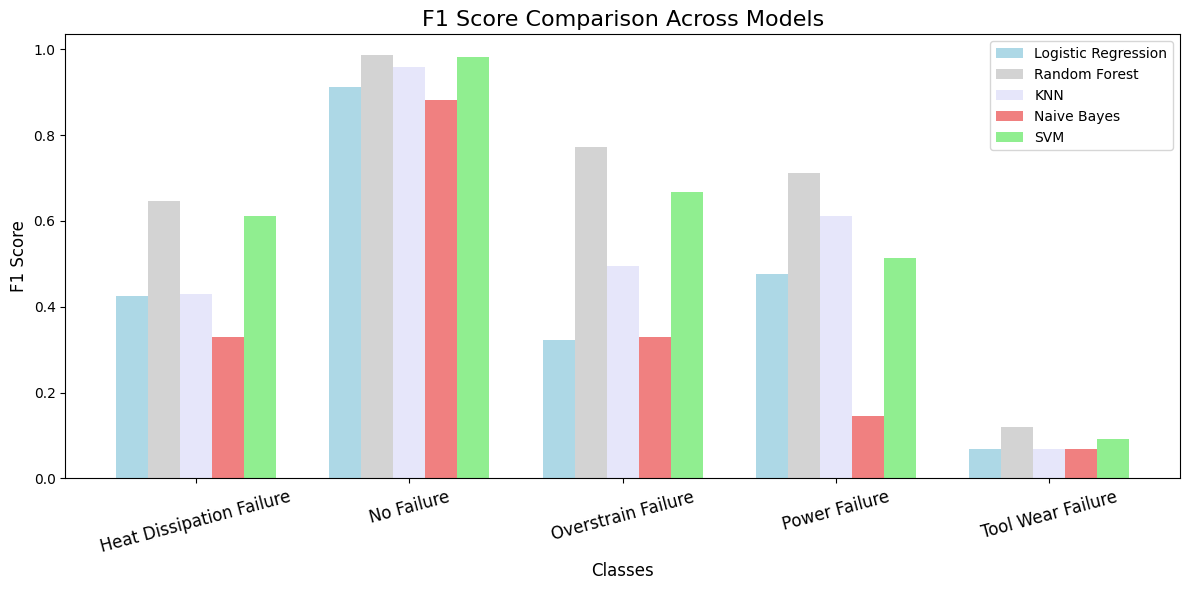

In [14]:
models = ['Logistic Regression', 'Random Forest', 'KNN', 'Naive Bayes', 'SVM']
colors = ['#ADD8E6', '#D3D3D3', '#E6E6FA', '#F08080', '#90EE90']

classes = list(f1_comparison.keys())
f1_scores_matrix = np.array([f1_comparison[class_label] for class_label in classes])

x = np.arange(len(classes))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(12, 6))

for i, (model, color) in enumerate(zip(models, colors)):
    ax.bar(x + i * bar_width, f1_scores_matrix[:, i], width=bar_width, label=model, color=color)

ax.set_xlabel('Classes', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score Comparison Across Models', fontsize=16)
ax.set_xticks(x + 2 * bar_width)
ax.set_xticklabels(classes, fontsize=12, rotation=15)
ax.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

In [18]:
%store -r lr_precision
%store -r rf_precision
%store -r knn_precision
%store -r nb_precision
%store -r svm_precision

In [33]:
def extract_precision_scores(class_report):
    return {class_label: class_report[class_label]['precision'] for class_label in class_report if class_label not in ['accuracy', 'macro avg', 'weighted avg']}

lr_precision_scores = extract_precision_scores(lr_class_report)
rf_precision_scores = extract_precision_scores(rf_class_report)
knn_precision_scores = extract_precision_scores(knn_class_report)
nb_precision_scores = extract_precision_scores(nb_class_report)
svm_precision_scores = extract_precision_scores(svm_class_report)

precision_comparison = {}
for class_label in lr_precision_scores.keys():
    precision_comparison[class_label] = [
        lr_precision_scores.get(class_label, 0),
        rf_precision_scores.get(class_label, 0),
        knn_precision_scores.get(class_label, 0),
        nb_precision_scores.get(class_label, 0),
        svm_precision_scores.get(class_label, 0)
    ]

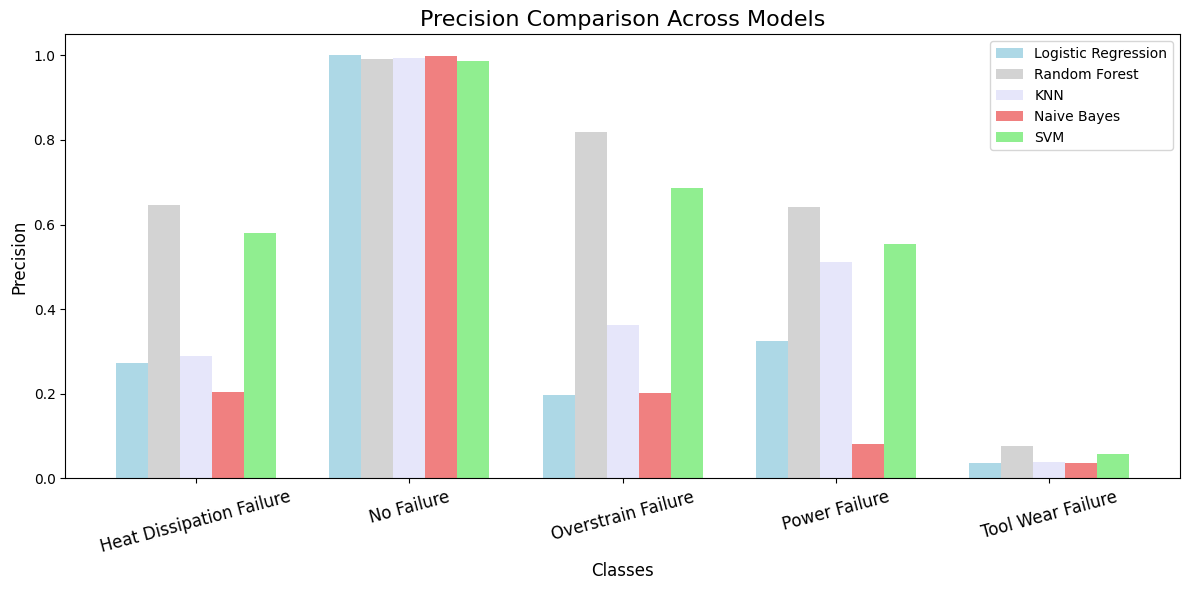

In [30]:
models = ['Logistic Regression', 'Random Forest', 'KNN', 'Naive Bayes', 'SVM']
colors = ['#ADD8E6', '#D3D3D3', '#E6E6FA', '#F08080', '#90EE90']

classes = list(precision_comparison.keys())
precision_scores_matrix = np.array([precision_comparison[class_label] for class_label in classes])

x = np.arange(len(classes))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(12, 6))

for i, (model, color) in enumerate(zip(models, colors)):
    ax.bar(x + i * bar_width, precision_scores_matrix[:, i], width=bar_width, label=model, color=color)

ax.set_xlabel('Classes', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision Comparison Across Models', fontsize=16)
ax.set_xticks(x + 2 * bar_width)
ax.set_xticklabels(classes, fontsize=12, rotation=15)
ax.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

In [15]:
%store -r lr_recall
%store -r rf_recall
%store -r knn_recall
%store -r nb_recall
%store -r svm_recall

In [32]:
def extract_recall_scores(class_report):
    return {class_label: class_report[class_label]['recall'] for class_label in class_report if class_label not in ['accuracy', 'macro avg', 'weighted avg']}

lr_recall_scores = extract_recall_scores(lr_class_report)
rf_recall_scores = extract_recall_scores(rf_class_report)
knn_recall_scores = extract_recall_scores(knn_class_report)
nb_recall_scores = extract_recall_scores(nb_class_report)
svm_recall_scores = extract_recall_scores(svm_class_report)

recall_comparison = {}
for class_label in lr_recall_scores.keys():
    recall_comparison[class_label] = [
        lr_recall_scores.get(class_label, 0),
        rf_recall_scores.get(class_label, 0),
        knn_recall_scores.get(class_label, 0),
        nb_recall_scores.get(class_label, 0),
        svm_recall_scores.get(class_label, 0)
    ]

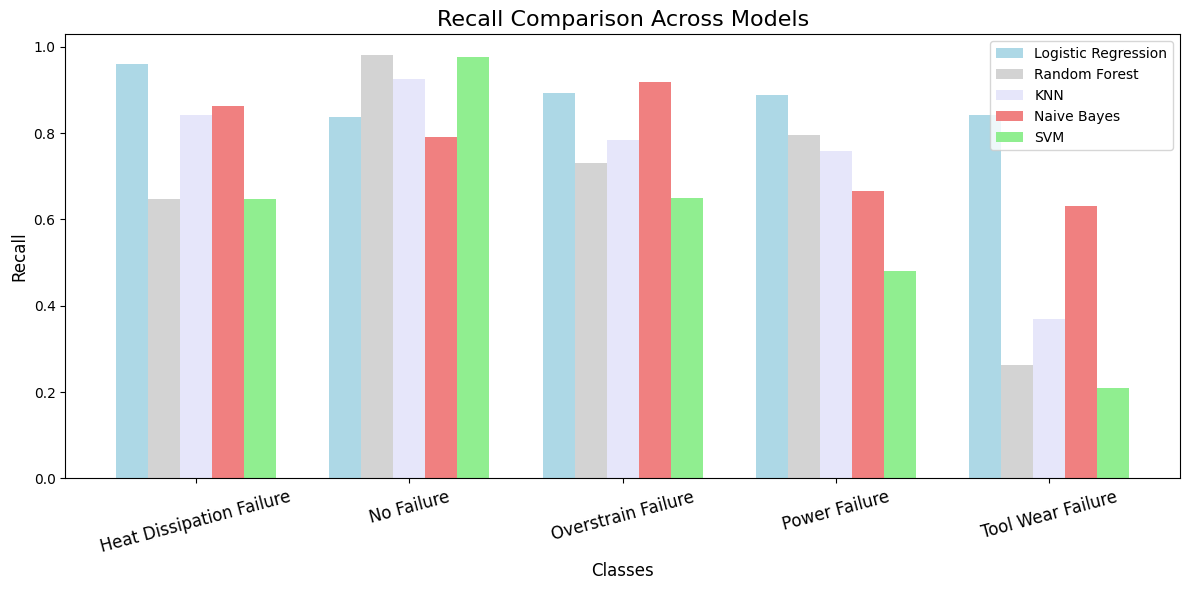

In [34]:
models = ['Logistic Regression', 'Random Forest', 'KNN', 'Naive Bayes', 'SVM']
colors = ['#ADD8E6', '#D3D3D3', '#E6E6FA', '#F08080', '#90EE90']

classes = list(recall_comparison.keys())
recall_scores_matrix = np.array([recall_comparison[class_label] for class_label in classes])

x = np.arange(len(classes))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(12, 6))

for i, (model, color) in enumerate(zip(models, colors)):
    ax.bar(x + i * bar_width, recall_scores_matrix[:, i], width=bar_width, label=model, color=color)

ax.set_xlabel('Classes', fontsize=12)
ax.set_ylabel('Recall', fontsize=12)
ax.set_title('Recall Comparison Across Models', fontsize=16)
ax.set_xticks(x + 2 * bar_width)
ax.set_xticklabels(classes, fontsize=12, rotation=15)
ax.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()